In [35]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

graph_metrics = pd.read_csv("enzyme_graph_metrics.csv")

node_attr = pd.read_csv("ENZYMES_node_attributes.txt", header=None)
node_attr.columns = [f"node_attr_{i+1}" for i in range(node_attr.shape[1])]

graph_indicator = pd.read_csv("ENZYMES_graph_indicator.txt", header=None, names=["graph_id"])

node_data = pd.concat([graph_indicator, node_attr], axis=1)

node_summary = node_data.groupby("graph_id").agg(["mean", "std"])
node_summary.columns = [f"{c[0]}_{c[1]}" for c in node_summary.columns]
node_summary = node_summary.reset_index()

df = pd.merge(graph_metrics, node_summary, on="graph_id")

X = df.drop(columns=["graph_id", "ec_class"])
y = df["ec_class"]

print(df.shape)
print(X.shape)

(600, 43)
(600, 41)


In [36]:
print(df.shape)
print(df.columns.tolist())

print(df["graph_id"].nunique(), "unique graph_ids")

print(df.isna().sum().sort_values(ascending=False).head(10))

print(df["ec_class"].value_counts())

print(df.describe())

(600, 43)
['graph_id', 'ec_class', 'node_count', 'edge_count', 'radius', 'diameter', 'mean_eigen_cent', 'node_attr_1_mean', 'node_attr_1_std', 'node_attr_2_mean', 'node_attr_2_std', 'node_attr_3_mean', 'node_attr_3_std', 'node_attr_4_mean', 'node_attr_4_std', 'node_attr_5_mean', 'node_attr_5_std', 'node_attr_6_mean', 'node_attr_6_std', 'node_attr_7_mean', 'node_attr_7_std', 'node_attr_8_mean', 'node_attr_8_std', 'node_attr_9_mean', 'node_attr_9_std', 'node_attr_10_mean', 'node_attr_10_std', 'node_attr_11_mean', 'node_attr_11_std', 'node_attr_12_mean', 'node_attr_12_std', 'node_attr_13_mean', 'node_attr_13_std', 'node_attr_14_mean', 'node_attr_14_std', 'node_attr_15_mean', 'node_attr_15_std', 'node_attr_16_mean', 'node_attr_16_std', 'node_attr_17_mean', 'node_attr_17_std', 'node_attr_18_mean', 'node_attr_18_std']
600 unique graph_ids
graph_id             0
node_attr_13_std     0
node_attr_9_std      0
node_attr_10_mean    0
node_attr_10_std     0
node_attr_11_mean    0
node_attr_11_std 

In [37]:
print(df.head())

   graph_id  ec_class  node_count  edge_count  radius  diameter  \
0         1         6          37         168       6        12   
1         2         6          23         102       4         8   
2         3         6          25          92       6        11   
3         4         6          24          90       6        12   
4         5         6          23          90       5         9   

   mean_eigen_cent  node_attr_1_mean  node_attr_1_std  node_attr_2_mean  ...  \
0         0.323953          7.756757         4.443506         12.753363  ...   
1         0.500626          9.434783         5.735266         15.357012  ...   
2         0.292045          9.240000         5.433538         14.165496  ...   
3         0.394724          8.875000         5.202946         13.915350  ...   
4         0.388649          9.913043         5.476504         15.458343  ...   

   node_attr_14_mean  node_attr_14_std  node_attr_15_mean  node_attr_15_std  \
0           2.027027          1.90739

In [38]:
# Separate features (X) and target (y)
X = df.drop(columns=["graph_id", "ec_class"])
y = df["ec_class"]

=== Random Forest With Node Aggregation: 6-Fold CV ===
Mean CV Accuracy: 0.6617
Mean CV Macro F1: 0.6598
Mean CV Precision: 0.6749
Mean CV Recall: 0.6614

Classification Report:

              precision    recall  f1-score   support

           1       0.60      0.52      0.56       100
           2       0.77      0.66      0.71       100
           3       0.63      0.72      0.67       100
           4       0.65      0.62      0.64       100
           5       0.70      0.70      0.70       100
           6       0.64      0.75      0.69       100

    accuracy                           0.66       600
   macro avg       0.66      0.66      0.66       600
weighted avg       0.66      0.66      0.66       600



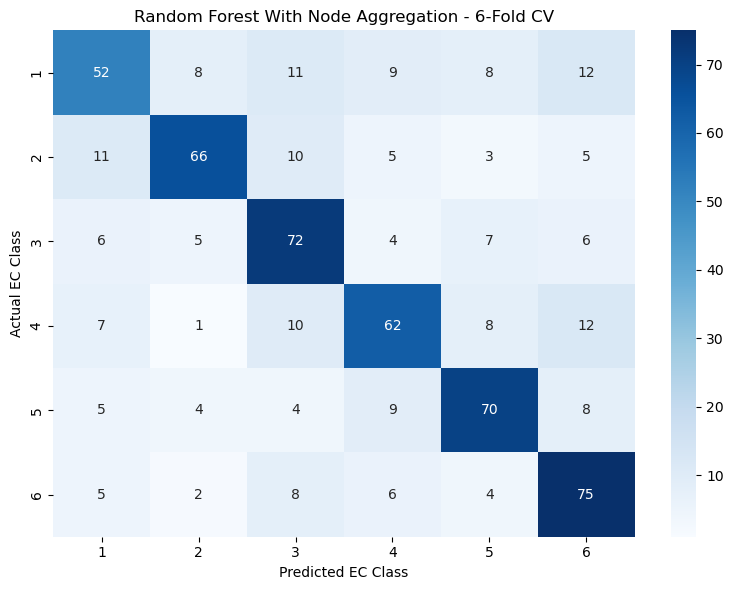

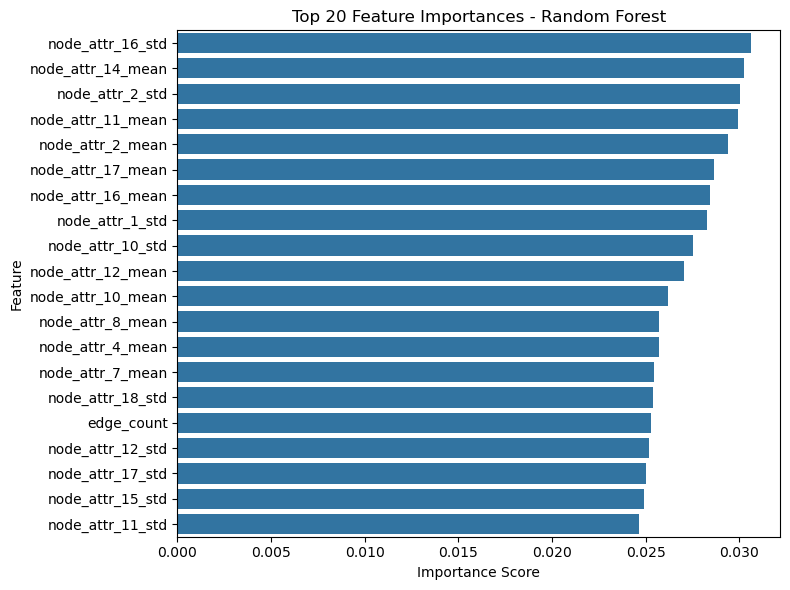

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Features and target
X = df.drop(columns=["graph_id", "ec_class"])
y = df["ec_class"]

# 6-fold stratified cross-validation
cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# Cross-validation scores
scores = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"],
    return_train_score=True
)

print("=== Random Forest With Node Aggregation: 6-Fold CV ===")
print("Mean CV Accuracy:", round(scores["test_accuracy"].mean(), 4))
print("Mean CV Macro F1:", round(scores["test_f1_macro"].mean(), 4))
print("Mean CV Precision:", round(scores["test_precision_macro"].mean(), 4))
print("Mean CV Recall:", round(scores["test_recall_macro"].mean(), 4))

# Get held-out predictions for every graph across CV folds
y_pred_cv = cross_val_predict(rf_model, X, y, cv=cv)

print("\nClassification Report:\n")
print(classification_report(y, y_pred_cv))

# Confusion matrix
cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel("Predicted EC Class")
plt.ylabel("Actual EC Class")
plt.title("Random Forest With Node Aggregation - 6-Fold CV")
plt.tight_layout()
plt.show()

# Fit model on full dataset for feature importance
rf_model.fit(X, y)

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot top 20 features only so graph is readable
top_n = 20
top_indices = indices[:top_n]

plt.figure(figsize=(8, 6))
sns.barplot(
    x=importances[top_indices],
    y=[feature_names[i] for i in top_indices]
)
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

=== XGBoost Baseline ===
Mean CV Accuracy: 0.6367
Mean CV Macro F1: 0.6338
Mean CV Precision: 0.6416
Mean CV Recall: 0.6364

Classification Report:

              precision    recall  f1-score   support

           1       0.58      0.51      0.54       100
           2       0.76      0.67      0.71       100
           3       0.67      0.70      0.69       100
           4       0.60      0.60      0.60       100
           5       0.62      0.64      0.63       100
           6       0.60      0.70      0.65       100

    accuracy                           0.64       600
   macro avg       0.64      0.64      0.64       600
weighted avg       0.64      0.64      0.64       600



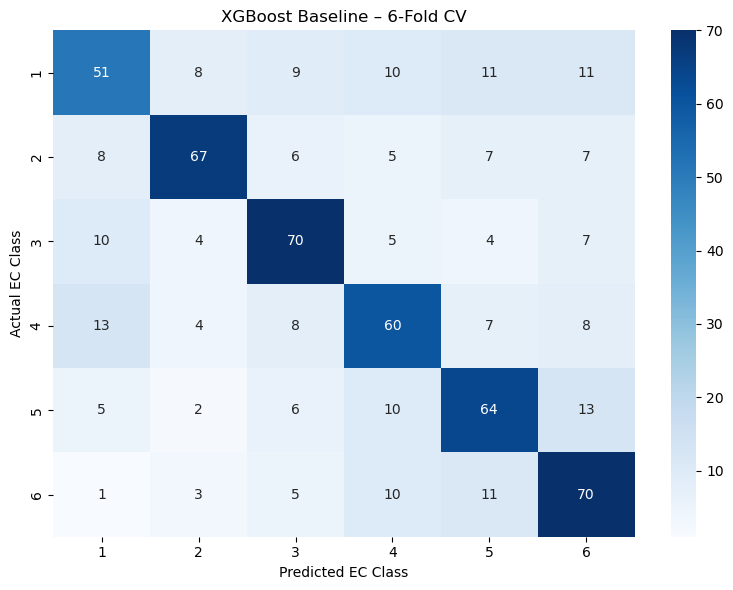

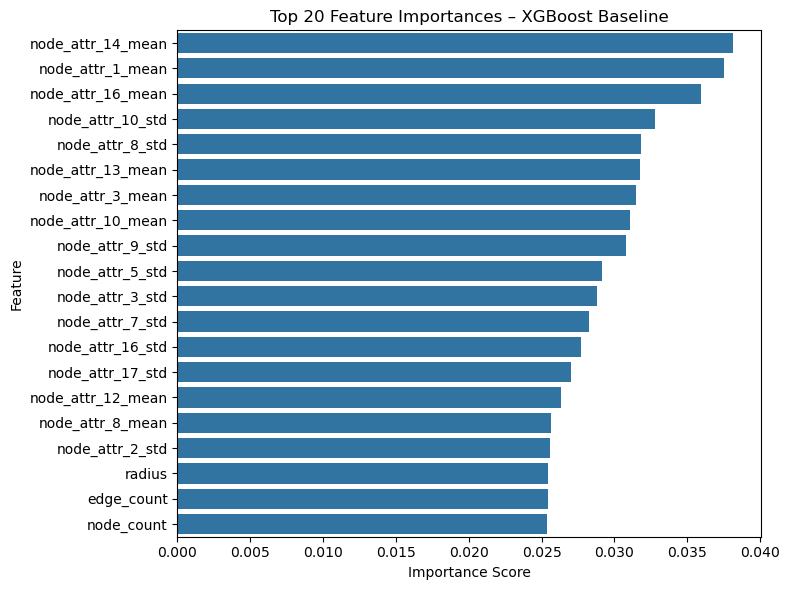

In [40]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X = df.drop(columns=["graph_id", "ec_class"])
y = df["ec_class"]
y_encoded = y - 1

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    eval_metric="mlogloss",
    random_state=42
)

scores = cross_validate(
    xgb_model,
    X,
    y_encoded,
    cv=cv,
    scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"]
)

print("=== XGBoost Baseline ===")
print("Mean CV Accuracy:", round(scores["test_accuracy"].mean(), 4))
print("Mean CV Macro F1:", round(scores["test_f1_macro"].mean(), 4))
print("Mean CV Precision:", round(scores["test_precision_macro"].mean(), 4))
print("Mean CV Recall:", round(scores["test_recall_macro"].mean(), 4))

y_pred = cross_val_predict(xgb_model, X, y_encoded, cv=cv)
y_pred = y_pred + 1

print("\nClassification Report:\n")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel("Predicted EC Class")
plt.ylabel("Actual EC Class")
plt.title("XGBoost Baseline – 6-Fold CV")
plt.tight_layout()
plt.show()

xgb_model.fit(X, y_encoded)

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 20
top_indices = indices[:top_n]

plt.figure(figsize=(8,6))
sns.barplot(
    x=importances[top_indices],
    y=[X.columns[i] for i in top_indices]
)
plt.title("Top 20 Feature Importances – XGBoost Baseline")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

=== SVM (With Node Aggregation) ===
Mean CV Accuracy: 0.5267
Mean CV Macro F1: 0.5024
Mean CV Precision: 0.5192
Mean CV Recall: 0.5262

Classification Report:

              precision    recall  f1-score   support

           1       0.36      0.15      0.21       100
           2       0.57      0.46      0.51       100
           3       0.57      0.63      0.60       100
           4       0.53      0.73      0.61       100
           5       0.58      0.53      0.55       100
           6       0.49      0.66      0.56       100

    accuracy                           0.53       600
   macro avg       0.51      0.53      0.51       600
weighted avg       0.51      0.53      0.51       600



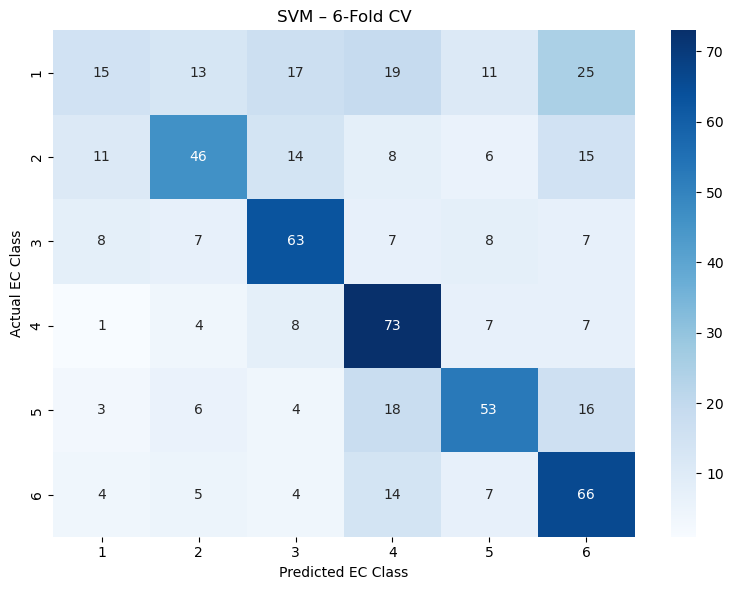

In [41]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_predict

# Pipeline = scaling + SVM
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale"))
])

# CV evaluation
scores = cross_validate(
    svm_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"],
    n_jobs=-1
)

print("=== SVM (With Node Aggregation) ===")
print("Mean CV Accuracy:", round(scores["test_accuracy"].mean(), 4))
print("Mean CV Macro F1:", round(scores["test_f1_macro"].mean(), 4))
print("Mean CV Precision:", round(scores["test_precision_macro"].mean(), 4))
print("Mean CV Recall:", round(scores["test_recall_macro"].mean(), 4))

# Predictions across folds
y_pred_cv = cross_val_predict(svm_model, X, y, cv=cv)

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:\n")
print(classification_report(y, y_pred_cv))

# Confusion matrix
cm = confusion_matrix(y, y_pred_cv)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Predicted EC Class")
plt.ylabel("Actual EC Class")
plt.title("SVM – 6-Fold CV")
plt.tight_layout()
plt.show()

In [42]:
X = df.drop(columns=["graph_id", "ec_class"])
y = df["ec_class"]

# XGBoost needs labels starting at 0
y_encoded = y - 1

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

In [43]:
cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

In [44]:
scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"],
    n_jobs=-1
)

print("=== Logistic Regression – 6-Fold CV ===")
print("Mean CV Accuracy:", round(scores["test_accuracy"].mean(), 4))
print("Mean CV Macro F1:", round(scores["test_f1_macro"].mean(), 4))
print("Mean CV Precision:", round(scores["test_precision_macro"].mean(), 4))
print("Mean CV Recall:", round(scores["test_recall_macro"].mean(), 4))

=== Logistic Regression – 6-Fold CV ===
Mean CV Accuracy: 0.4633
Mean CV Macro F1: 0.4495
Mean CV Precision: 0.4527
Mean CV Recall: 0.4635


In [45]:
y_pred_cv = cross_val_predict(model, X, y, cv=cv)

print("\nClassification Report:\n")
print(classification_report(y, y_pred_cv))


Classification Report:

              precision    recall  f1-score   support

           1       0.31      0.20      0.24       100
           2       0.49      0.47      0.48       100
           3       0.53      0.55      0.54       100
           4       0.43      0.49      0.46       100
           5       0.48      0.53      0.50       100
           6       0.49      0.54      0.51       100

    accuracy                           0.46       600
   macro avg       0.45      0.46      0.46       600
weighted avg       0.45      0.46      0.46       600



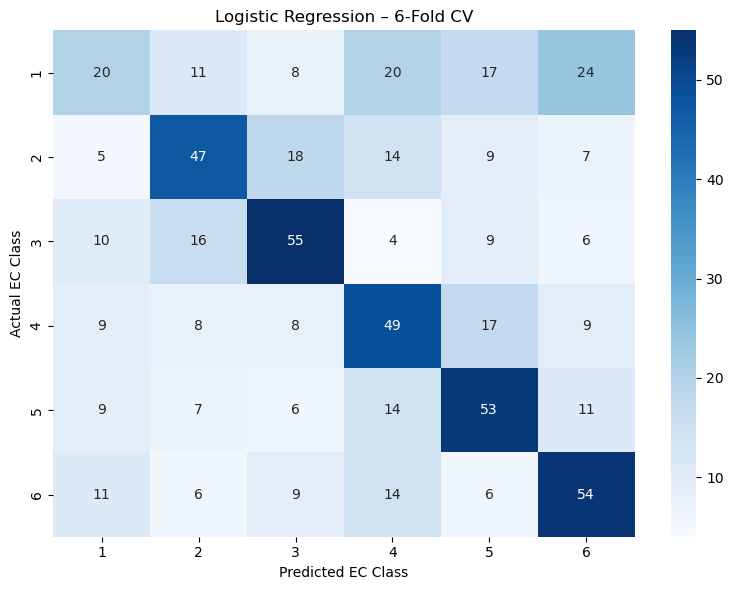

In [46]:
cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel("Predicted EC Class")
plt.ylabel("Actual EC Class")
plt.title("Logistic Regression – 6-Fold CV")
plt.tight_layout()
plt.show()

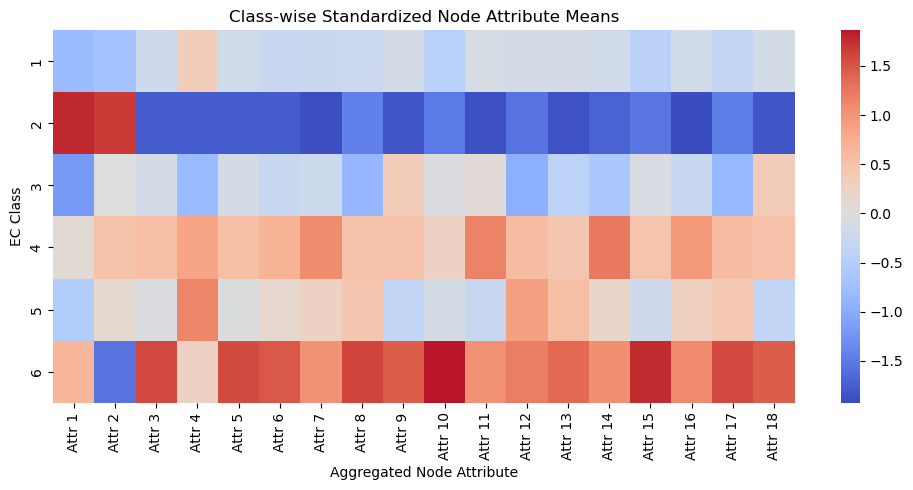

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Select node attribute mean columns
mean_cols = [col for col in df.columns if "node_attr" in col and "_mean" in col]

# Compute class-wise means
class_node_means = df.groupby("ec_class")[mean_cols].mean()

# Standardize across attributes (so one feature doesn’t dominate)
scaler = StandardScaler()
scaled_values = scaler.fit_transform(class_node_means)

scaled_df = pd.DataFrame(
    scaled_values,
    index=class_node_means.index,
    columns=class_node_means.columns
)

# Optional: clean column names for readability
scaled_df.columns = [
    col.replace("node_attr_", "Attr ").replace("_mean", "")
    for col in scaled_df.columns
]

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    scaled_df,
    cmap="coolwarm",
    center=0
)

plt.title("Class-wise Standardized Node Attribute Means")
plt.xlabel("Aggregated Node Attribute")
plt.ylabel("EC Class")
plt.tight_layout()
plt.show()